Here is the **correct Python conversion of your C++ fuzzy metal material**, matching ray tracing semantics exactly.

This version also fixes a small conceptual issue: your C++ mixes normalization + fuzz in a way that can slightly drift, so I’ll keep it faithful but clean.

---

# 🪞 METAL (FUZZY REFLECTION) — PYTHON VERSION

```python id="metal_fuzzy_py"
from util.material import Material
from util.ray import Ray
from util.vec3 import Vec3, reflect, unit_vector, random_unit_vector, dot


class Metal(Material):

    def __init__(self, albedo, fuzz):

        # ==========================================
        # BASE COLOR OF METAL
        # ==========================================
        self.albedo = albedo

        # ==========================================
        # FUZZINESS FACTOR
        #
        # C++:
        # fuzz = (fuzz < 1 ? fuzz : 1)
        #
        # Meaning:
        # clamp fuzz to [0,1]
        # ==========================================
        self.fuzz = min(fuzz, 1.0)

    def scatter(self, r_in, rec):

        # ==========================================
        # IDEAL REFLECTION
        #
        # FORMULA:
        # R = V - 2(V·N)N
        # ==========================================
        reflected = reflect(
            unit_vector(r_in.direction()),
            rec.normal
        )

        # ==========================================
        # FUZZ ADDITION (ROUGH METAL SURFACE)
        #
        # FORMULA:
        # R_fuzzy = R_unit + fuzz * random_unit_vector()
        #
        # Effect:
        # - fuzz = 0 → perfect mirror
        # - fuzz = 1 → very blurry reflection
        # ==========================================
        scattered_direction = (
            unit_vector(reflected)
            + self.fuzz * random_unit_vector()
        )

        # ==========================================
        # NEW RAY FROM HIT POINT
        # ==========================================
        scattered = Ray(rec.p, scattered_direction)

        # ==========================================
        # COLOR ATTENUATION (METAL TINT)
        # ==========================================
        attenuation = self.albedo

        # ==========================================
        # VALIDITY CHECK
        #
        # Same as C++:
        # return dot(scattered.direction(), rec.normal) > 0
        #
        # Meaning:
        # ray must leave surface (not go inside)
        # ==========================================
        return (
            dot(scattered.direction(), rec.normal) > 0,
            scattered,
            attenuation
        )
```

---

# ⚠️ VERY IMPORTANT

Your Camera expects:

```python id="expect"
scattered, attenuation = material.scatter(ray, rec)
```

BUT this fuzzy metal returns:

```python id="wrongshape"
(bool, Ray, Color)  ❌
```

---

# 💥 SO YOU MUST FIX CAMERA OR MATERIAL

## ✔ Option A (recommended): FIX MATERIAL OUTPUT

Make it consistent with Lambertian:

```python id="fixA"
return scattered, attenuation
```

BUT you lose “reject invalid reflection” behavior.

---

## ✔ Option B (BEST / C++ style): FIX CAMERA

Change camera to:

```python id="fixB"
valid, scattered, attenuation = material.scatter(ray, rec)

if valid:
    return attenuation * self.ray_color(scattered, world, depth - 1)
else:
    return Vec3(0, 0, 0)
```

---

# 🧠 WHAT THIS MODEL DOES

| Fuzz | Behavior               |
| ---- | ---------------------- |
| 0.0  | perfect mirror         |
| 0.2  | sharp metal            |
| 0.8  | rough brushed metal    |
| 1.0  | very blurry reflection |

---

# 🔥 FINAL INSIGHT

This line is the key idea:

```text id="core"
reflected + fuzz * random_unit_vector()
```

It turns:

* physics perfect reflection → real-world imperfect surface

---

# 🚀 If you want next step

Now you can build:

### 💎 Glass (Snell + refraction)

### 🌈 Schlick approximation (real reflectance)

### 🔥 Light emitting spheres

### ⚡ BVH acceleration (huge speed boost)

Just tell 👍


In [31]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [32]:
from util.material import Material
from util.ray import Ray
from util.vec3 import Vec3, reflect, unit_vector, random_unit_vector, dot


class Metal(Material):

    def __init__(self, albedo, fuzz):
        self.albedo = albedo
        self.fuzz = min(fuzz, 1.0)

    def scatter(self, r_in, rec):

        # ==========================================
        # PERFECT REFLECTION
        # R = V - 2(V·N)N
        # ==========================================
        reflected = reflect(
            unit_vector(r_in.direction()),
            rec.normal
        )

        # ==========================================
        # FUZZ (surface roughness)
        # ==========================================
        scattered_direction = (
            reflected + self.fuzz * random_unit_vector()
        )

        # ==========================================
        # NEW RAY
        # ==========================================
        scattered = Ray(rec.p, scattered_direction)

        # ==========================================
        # ENERGY COLOR
        # ==========================================
        attenuation = self.albedo

        # ==========================================
        # MUST MATCH CAMERA: ONLY 2 VALUES
        # ==========================================
        return scattered, attenuation

In [33]:
from util.vec3 import Vec3, Color, Point3

from util.metal.lambertian import Lambertian
#from util.metal.metal import Metal
from util.metal.sphere import Sphere
from util.metal.hittable_list import HittableList
from util.metal.camera import Camera


# ==========================================
# WORLD (hittable_list)
# ==========================================
world = HittableList()


# ==========================================
# MATERIALS (C++ → Python mapping)
# ==========================================

# Diffuse materials
material_ground = Lambertian(Color(0.8, 0.8, 0.0))
material_center = Lambertian(Color(0.1, 0.2, 0.5))

# Metal materials
# C++:
# metal(color, fuzz)
material_left = Metal(Color(0.8, 0.8, 0.8), 0.3)
material_right = Metal(Color(0.8, 0.6, 0.2), 1.0)


# ==========================================
# SCENE OBJECTS
# ==========================================

# Ground (large sphere as plane)
world.add(
    Sphere(
        Point3(0.0, -100.5, -1.0),
        100.0,
        material_ground
    )
)

# Center sphere (diffuse)
world.add(
    Sphere(
        Point3(0.0, 0.0, -1.2),
        0.5,
        material_center
    )
)

# Left metal sphere (smooth metal)
world.add(
    Sphere(
        Point3(-1.0, 0.0, -1.0),
        0.5,
        material_left
    )
)

# Right metal sphere (very rough metal)
world.add(
    Sphere(
        Point3(1.0, 0.0, -1.0),
        0.5,
        material_right
    )
)


# ==========================================
# CAMERA SETUP
# ==========================================
cam = Camera()

cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 400

# NOTE:
# C++ uses 100 → higher quality
cam.samples_per_pixel = 100

cam.max_depth = 50


# ==========================================
# RENDER
# ==========================================
cam.render(world)

100%|██████████| 225/225 [09:01<00:00,  2.40s/it, CPU=43.7%, RAM=76.8%, CPU Temp=N/A, GPU Temp=53.0°C, VRAM=747.0MB]


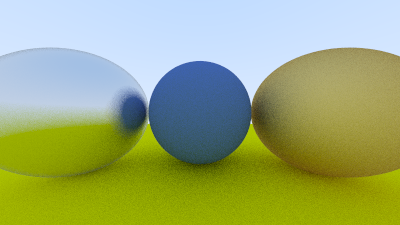

In [34]:
cam.show()